# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [12]:
# **IMPORTANT** when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-aa
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ab
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ac
!wget https://github.com/justheuristic/junk/raw/refs/heads/cifar10-part/dataset.tar.part-ad
!cat dataset.tar.part-* | tar -xvf -
!mkdir cifar_data
!mv dataset/cifar-10-batches-py/  cifar_data/cifar-10-batches-py/

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget
x dataset/
x dataset/cifar-10-batches-py/
x dataset/cifar-10-batches-py/readme.html
x dataset/cifar-10-batches-py/data_batch_2
x dataset/cifar-10-batches-py/data_batch_5
x dataset/cifar-10-batches-py/data_batch_3
x dataset/cifar-10-batches-py/data_batch_1
x dataset/cifar-10-batches-py/test_batch
x dataset/cifar-10-batches-py/data_batch_4
x dataset/cifar-10-batches-py/batches.meta
mkdir: cifar_data: File exists


In [13]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


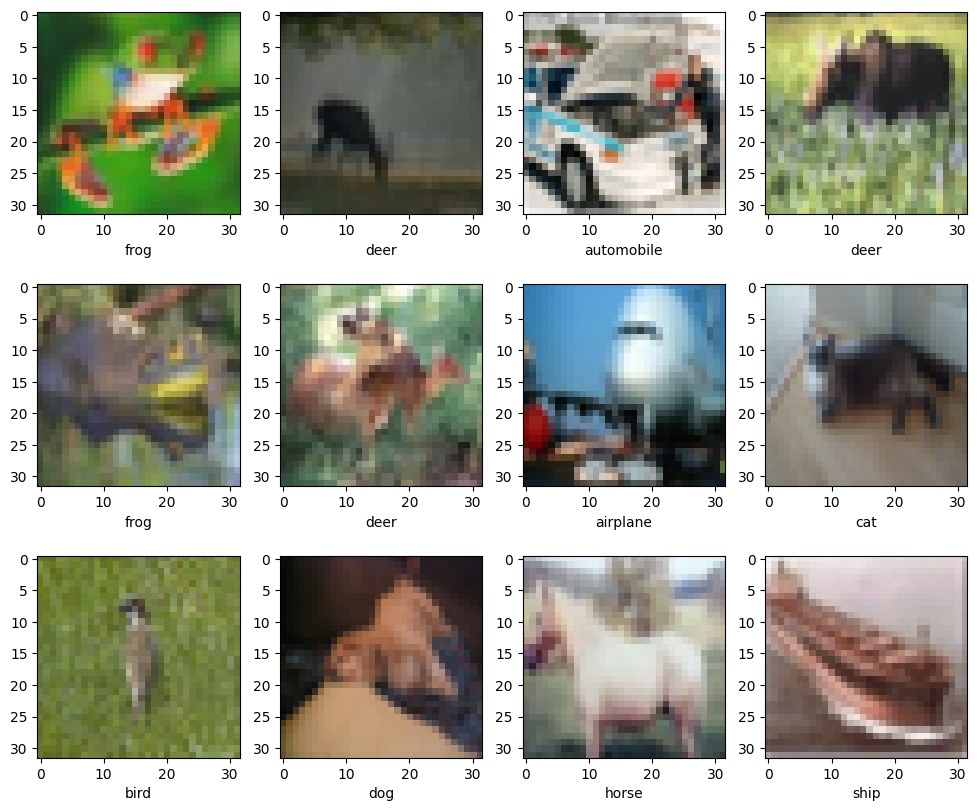

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(3 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # logits for 10 classes. No softmax - this is intentional
)

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [16]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [17]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.2737, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [18]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [19]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 0.654s
  training loss (in-iteration): 	2.021147
  validation accuracy: 			34.57 %
Epoch 2 of 100 took 0.629s
  training loss (in-iteration): 	1.853421
  validation accuracy: 			37.12 %
Epoch 3 of 100 took 0.622s
  training loss (in-iteration): 	1.782871
  validation accuracy: 			39.43 %
Epoch 4 of 100 took 0.618s
  training loss (in-iteration): 	1.732705
  validation accuracy: 			39.67 %
Epoch 5 of 100 took 0.617s
  training loss (in-iteration): 	1.689969
  validation accuracy: 			41.85 %
Epoch 6 of 100 took 0.574s
  training loss (in-iteration): 	1.656632
  validation accuracy: 			42.45 %
Epoch 7 of 100 took 0.590s
  training loss (in-iteration): 	1.626442
  validation accuracy: 			44.24 %
Epoch 8 of 100 took 0.644s
  training loss (in-iteration): 	1.601519
  validation accuracy: 			44.75 %
Epoch 9 of 100 took 0.623s
  training loss (in-iteration): 	1.578287
  validation accuracy: 			44.81 %
Epoch 10 of 100 took 0.576s
  training loss (in-iteration): 	1.558203
  v

KeyboardInterrupt: 

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [20]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		51.35 %
Achievement unlocked: 60lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [21]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=10,
        kernel_size=3
    ),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(10 * 15 * 15, 100),
    nn.ReLU(),

    nn.Dropout(0.1),

    nn.Linear(100,10)
)

In [19]:
x = torch.as_tensor(
    X_train[:5],
    dtype=torch.float32
)

print("input:", x.shape)

with torch.no_grad():
    for layer in model:
        x = layer(x)
        print(
            f"{layer.__class__.__name__:12s}",
            x.shape
        )

input: torch.Size([5, 3, 32, 32])
Conv2d       torch.Size([5, 10, 30, 30])
ReLU         torch.Size([5, 10, 30, 30])
MaxPool2d    torch.Size([5, 10, 15, 15])
Flatten      torch.Size([5, 2250])
Linear       torch.Size([5, 100])
ReLU         torch.Size([5, 100])
Dropout      torch.Size([5, 100])
Linear       torch.Size([5, 10])


In [20]:
opt = torch.optim.Adam(
    model.parameters()
)

train_loss = []
val_accuracy = []

In [21]:
import time

num_epochs = 25
batch_size = 50

for epoch in range(num_epochs):

    start_time = time.time()

    model.train(True)

    for X_batch, y_batch in iterate_minibatches(
        X_train,
        y_train,
        batch_size
    ):

        loss = compute_loss(
            X_batch,
            y_batch
        )

        loss.backward()
        opt.step()
        opt.zero_grad()

        train_loss.append(
            loss.item()
        )

    model.train(False)

    with torch.no_grad():

        for X_batch, y_batch in iterate_minibatches(
            X_val,
            y_val,
            batch_size
        ):

            logits = model(
                torch.as_tensor(
                    X_batch,
                    dtype=torch.float32
                )
            )

            y_pred = (
                logits
                .argmax(-1)
                .detach()
                .numpy()
            )

            val_accuracy.append(
                np.mean(
                    y_batch == y_pred
                )
            )

    print(
        "Epoch {} of {} took {:.3f}s".format(
            epoch + 1,
            num_epochs,
            time.time() - start_time
        )
    )

    print(
        "  training loss: \t{:.6f}".format(
            np.mean(
                train_loss[
                    -len(X_train) // batch_size:
                ]
            )
        )
    )

    print(
        "  validation accuracy: \t{:.2f} %".format(
            np.mean(
                val_accuracy[
                    -len(X_val) // batch_size:
                ]
            ) * 100
        )
    )

Epoch 1 of 25 took 4.837s
  training loss: 	1.691589
  validation accuracy: 	47.88 %
Epoch 2 of 25 took 4.414s
  training loss: 	1.409340
  validation accuracy: 	53.20 %
Epoch 3 of 25 took 4.533s
  training loss: 	1.286345
  validation accuracy: 	54.89 %
Epoch 4 of 25 took 4.449s
  training loss: 	1.217540
  validation accuracy: 	56.97 %
Epoch 5 of 25 took 4.407s
  training loss: 	1.163128
  validation accuracy: 	57.46 %
Epoch 6 of 25 took 4.410s
  training loss: 	1.114688
  validation accuracy: 	58.64 %
Epoch 7 of 25 took 4.386s
  training loss: 	1.072001
  validation accuracy: 	58.67 %
Epoch 8 of 25 took 4.369s
  training loss: 	1.039665
  validation accuracy: 	59.96 %
Epoch 9 of 25 took 4.402s
  training loss: 	1.007835
  validation accuracy: 	59.99 %
Epoch 10 of 25 took 4.398s
  training loss: 	0.974977
  validation accuracy: 	60.66 %
Epoch 11 of 25 took 4.436s
  training loss: 	0.940818
  validation accuracy: 	59.72 %
Epoch 12 of 25 took 4.406s
  training loss: 	0.916258
  validat

In [22]:
print(
    f"Best validation accuracy: "
    f"{max(val_accuracy) * 100:.2f}%"
)

Best validation accuracy: 84.00%


```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [28]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=10,
        kernel_size=3
    ),

    nn.BatchNorm2d(10),

    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(
        10 * 15 * 15,
        100
    ),
    nn.ReLU(),

    nn.Dropout(0.1),

    nn.Linear(
        100,
        10
    )
)

In [29]:
x = torch.as_tensor(
    X_train[:5],
    dtype=torch.float32
)

print("input:", x.shape)

with torch.no_grad():
    for layer in model:
        x = layer(x)
        print(
            f"{layer.__class__.__name__:12s}",
            x.shape
        )

input: torch.Size([5, 3, 32, 32])
Conv2d       torch.Size([5, 10, 30, 30])
BatchNorm2d  torch.Size([5, 10, 30, 30])
ReLU         torch.Size([5, 10, 30, 30])
MaxPool2d    torch.Size([5, 10, 15, 15])
Flatten      torch.Size([5, 2250])
Linear       torch.Size([5, 100])
ReLU         torch.Size([5, 100])
Dropout      torch.Size([5, 100])
Linear       torch.Size([5, 10])


In [30]:
opt = torch.optim.Adam(
    model.parameters()
)

train_loss = []
val_accuracy = []

In [27]:
import time

num_epochs = 15
batch_size = 50

for epoch in range(num_epochs):

    start_time = time.time()

    model.train(True)

    for X_batch, y_batch in iterate_minibatches(
        X_train,
        y_train,
        batch_size
    ):

        loss = compute_loss(
            X_batch,
            y_batch
        )

        loss.backward()
        opt.step()
        opt.zero_grad()

        train_loss.append(
            loss.item()
        )

    model.train(False)

    with torch.no_grad():

        for X_batch, y_batch in iterate_minibatches(
            X_val,
            y_val,
            batch_size
        ):

            logits = model(
                torch.as_tensor(
                    X_batch,
                    dtype=torch.float32
                )
            )

            y_pred = (
                logits
                .argmax(-1)
                .detach()
                .numpy()
            )

            val_accuracy.append(
                np.mean(
                    y_batch == y_pred
                )
            )

    print(
        "Epoch {} of {} took {:.3f}s".format(
            epoch + 1,
            num_epochs,
            time.time() - start_time
        )
    )

    print(
        "  training loss: \t{:.6f}".format(
            np.mean(
                train_loss[
                    -len(X_train) // batch_size:
                ]
            )
        )
    )

    print(
        "  validation accuracy: \t{:.2f} %".format(
            np.mean(
                val_accuracy[
                    -len(X_val) // batch_size:
                ]
            ) * 100
        )
    )

Epoch 1 of 15 took 5.792s
  training loss: 	0.501925
  validation accuracy: 	59.32 %
Epoch 2 of 15 took 5.157s
  training loss: 	0.486504
  validation accuracy: 	59.20 %
Epoch 3 of 15 took 5.174s
  training loss: 	0.476380
  validation accuracy: 	59.25 %
Epoch 4 of 15 took 5.017s
  training loss: 	0.474205
  validation accuracy: 	58.35 %
Epoch 5 of 15 took 5.026s
  training loss: 	0.461290
  validation accuracy: 	59.19 %
Epoch 6 of 15 took 5.460s
  training loss: 	0.455002
  validation accuracy: 	57.98 %
Epoch 7 of 15 took 5.596s
  training loss: 	0.432958
  validation accuracy: 	59.48 %
Epoch 8 of 15 took 5.643s
  training loss: 	0.432810
  validation accuracy: 	56.19 %
Epoch 9 of 15 took 5.450s
  training loss: 	0.429286
  validation accuracy: 	59.46 %
Epoch 10 of 15 took 5.431s
  training loss: 	0.419560
  validation accuracy: 	57.45 %
Epoch 11 of 15 took 5.167s
  training loss: 	0.417829
  validation accuracy: 	59.66 %
Epoch 12 of 15 took 5.061s
  training loss: 	0.398719
  validat


```

## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [46]:
from torchvision import transforms

means = (0.4914, 0.4822, 0.4465)
stds = (0.2023, 0.1994, 0.2010)

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [47]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

train_dataset_aug = CIFAR10(
    "./cifar_data/",
    train=True,
    transform=transform_augment
)

train_dataset_plain = CIFAR10(
    "./cifar_data/",
    train=True,
    transform=transform_test
)

all_indices = np.arange(len(train_dataset_aug))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=1337
)

train_dataset = Subset(
    train_dataset_aug,
    train_indices
)

val_dataset = Subset(
    train_dataset_plain,
    val_indices
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=1
)

X: <class 'torch.Tensor'> torch.Size([32, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([32])


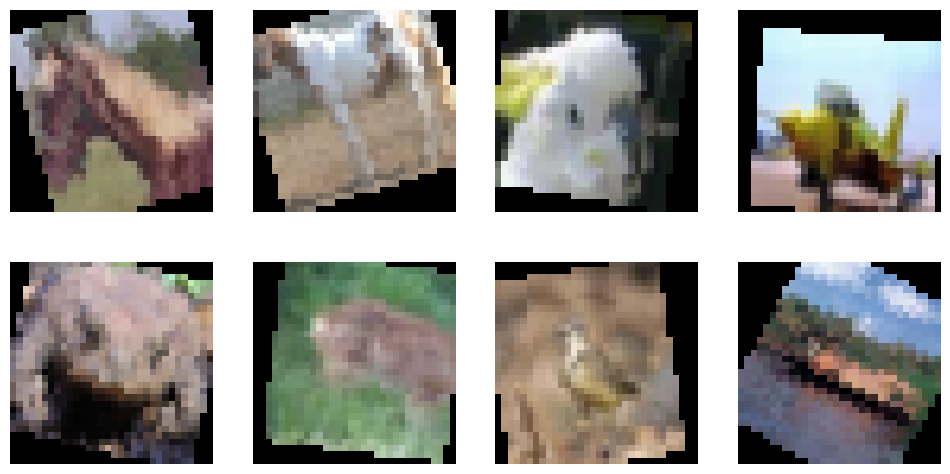

In [48]:
for x_batch, y_batch in train_dataloader:

    print("X:", type(x_batch), x_batch.shape)
    print("y:", type(y_batch), y_batch.shape)

    plt.figure(figsize=(12, 6))

    for i, img in enumerate(x_batch.numpy()[:8]):

        img = (
            img.transpose([1, 2, 0])
            * np.array(stds)
            + np.array(means)
        )

        img = np.clip(img, 0, 1)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

    break

When testing, we don't need random crops, just normalize with same statistics.

In [50]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=10,
        kernel_size=3
    ),
    nn.BatchNorm2d(10),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(
        10 * 15 * 15,
        100
    ),
    nn.ReLU(),

    nn.Dropout(0.1),

    nn.Linear(
        100,
        10
    )
)

opt = torch.optim.Adam(
    model.parameters()
)

In [51]:
import copy
import time

num_epochs = 25

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None

for epoch in range(num_epochs):

    start_time = time.time()

    # ---------- train ----------
    model.train()

    train_losses = []

    for x_batch, y_batch in train_dataloader:

        logits = model(x_batch)

        loss = F.cross_entropy(
            logits,
            y_batch
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_losses.append(
            loss.item()
        )

    # ---------- validation ----------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_dataloader:

            logits = model(x_batch)

            y_pred = logits.argmax(
                dim=1
            )

            val_correct += (
                y_pred == y_batch
            ).sum().item()

            val_total += y_batch.size(0)

    current_val_accuracy = (
        val_correct / val_total
    )

    # ---------- save best ----------
    if current_val_accuracy > best_val_accuracy:

        best_val_accuracy = current_val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"loss {np.mean(train_losses):.4f} | "
        f"val {current_val_accuracy * 100:.2f}% | "
        f"best {best_val_accuracy * 100:.2f}% "
        f"(epoch {best_epoch}) | "
        f"time {time.time() - start_time:.1f}s"
    )

Epoch 01/25 | loss 1.8103 | val 40.37% | best 40.37% (epoch 1) | time 19.3s
Epoch 02/25 | loss 1.6375 | val 45.55% | best 45.55% (epoch 2) | time 18.8s
Epoch 03/25 | loss 1.5884 | val 46.40% | best 46.40% (epoch 3) | time 18.5s
Epoch 04/25 | loss 1.5679 | val 47.97% | best 47.97% (epoch 4) | time 18.9s
Epoch 05/25 | loss 1.5451 | val 49.66% | best 49.66% (epoch 5) | time 18.8s
Epoch 06/25 | loss 1.5225 | val 49.33% | best 49.66% (epoch 5) | time 18.7s
Epoch 07/25 | loss 1.5018 | val 51.87% | best 51.87% (epoch 7) | time 18.8s
Epoch 08/25 | loss 1.4887 | val 50.57% | best 51.87% (epoch 7) | time 18.6s
Epoch 09/25 | loss 1.4703 | val 52.11% | best 52.11% (epoch 9) | time 18.5s
Epoch 10/25 | loss 1.4669 | val 51.87% | best 52.11% (epoch 9) | time 18.4s
Epoch 11/25 | loss 1.4572 | val 52.17% | best 52.17% (epoch 11) | time 18.4s
Epoch 12/25 | loss 1.4497 | val 52.96% | best 52.96% (epoch 12) | time 18.3s
Epoch 13/25 | loss 1.4415 | val 52.56% | best 52.96% (epoch 12) | time 19.1s
Epoch 14/

KeyboardInterrupt: 

In [52]:
model.load_state_dict(
    best_model_state
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}% "
    f"at epoch {best_epoch}"
)

Best validation accuracy: 55.41% at epoch 21


In [11]:
test_dataset = CIFAR10(
    "./cifar_data/",
    train=False,
    transform=transform_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=1
)

NameError: name 'CIFAR10' is not defined

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [54]:
model = nn.Sequential(
    # ---------- Block 1 ----------
    # [B, 3, 32, 32]
    nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(
        in_channels=32,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.MaxPool2d(2),

    # ---------- Block 2 ----------
    # [B, 32, 16, 16]
    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Conv2d(
        in_channels=64,
        out_channels=64,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.MaxPool2d(2),

    # ---------- Classifier ----------
    # [B, 64, 8, 8]
    nn.Flatten(),

    nn.Linear(
        64 * 8 * 8,
        256
    ),
    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(
        256,
        10
    )
)

opt = torch.optim.Adam(
    model.parameters()
)

In [55]:
x = torch.randn(
    5,
    3,
    32,
    32
)

print("Input:", x.shape)

with torch.no_grad():
    for layer in model:
        x = layer(x)

        print(
            f"{layer.__class__.__name__:15s}",
            x.shape
        )

Input: torch.Size([5, 3, 32, 32])
Conv2d          torch.Size([5, 32, 32, 32])
BatchNorm2d     torch.Size([5, 32, 32, 32])
ReLU            torch.Size([5, 32, 32, 32])
Conv2d          torch.Size([5, 32, 32, 32])
BatchNorm2d     torch.Size([5, 32, 32, 32])
ReLU            torch.Size([5, 32, 32, 32])
MaxPool2d       torch.Size([5, 32, 16, 16])
Conv2d          torch.Size([5, 64, 16, 16])
BatchNorm2d     torch.Size([5, 64, 16, 16])
ReLU            torch.Size([5, 64, 16, 16])
Conv2d          torch.Size([5, 64, 16, 16])
BatchNorm2d     torch.Size([5, 64, 16, 16])
ReLU            torch.Size([5, 64, 16, 16])
MaxPool2d       torch.Size([5, 64, 8, 8])
Flatten         torch.Size([5, 4096])
Linear          torch.Size([5, 256])
ReLU            torch.Size([5, 256])
Dropout         torch.Size([5, 256])
Linear          torch.Size([5, 10])


In [56]:
import copy
import time

num_epochs = 40
patience = 10

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0

history = []

for epoch in range(num_epochs):

    start_time = time.time()

    # ========================
    # Training
    # ========================
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_dataloader:

        opt.zero_grad()

        logits = model(x_batch)

        loss = F.cross_entropy(
            logits,
            y_batch
        )

        loss.backward()
        opt.step()

        train_loss += (
            loss.item()
            * x_batch.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        train_correct += (
            predictions == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    train_loss /= train_total

    train_accuracy = (
        train_correct / train_total
    )

    # ========================
    # Validation
    # ========================
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_dataloader:

            logits = model(x_batch)

            predictions = logits.argmax(
                dim=1
            )

            val_correct += (
                predictions == y_batch
            ).sum().item()

            val_total += y_batch.size(0)

    val_accuracy = (
        val_correct / val_total
    )

    # ========================
    # Save best model
    # ========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"loss {train_loss:.4f} | "
        f"train {train_accuracy * 100:.2f}% | "
        f"val {val_accuracy * 100:.2f}% | "
        f"best {best_val_accuracy * 100:.2f}% "
        f"(epoch {best_epoch}) | "
        f"time {time.time() - start_time:.1f}s"
    )

    # ========================
    # Early stopping
    # ========================
    if epochs_without_improvement >= patience:

        print(
            f"Early stopping: "
            f"validation has not improved "
            f"for {patience} epochs."
        )

        break

Epoch 01/40 | loss 1.7183 | train 36.59% | val 52.21% | best 52.21% (epoch 1) | time 85.7s
Epoch 02/40 | loss 1.4656 | train 46.13% | val 54.04% | best 54.04% (epoch 2) | time 85.3s
Epoch 03/40 | loss 1.3548 | train 50.60% | val 62.51% | best 62.51% (epoch 3) | time 86.2s
Epoch 04/40 | loss 1.2883 | train 53.55% | val 64.91% | best 64.91% (epoch 4) | time 85.7s
Epoch 05/40 | loss 1.2284 | train 55.96% | val 67.48% | best 67.48% (epoch 5) | time 86.3s
Epoch 06/40 | loss 1.1894 | train 57.49% | val 68.57% | best 68.57% (epoch 6) | time 86.2s
Epoch 07/40 | loss 1.1492 | train 59.29% | val 69.54% | best 69.54% (epoch 7) | time 85.6s
Epoch 08/40 | loss 1.1062 | train 60.67% | val 71.25% | best 71.25% (epoch 8) | time 85.2s
Epoch 09/40 | loss 1.0818 | train 62.11% | val 72.05% | best 72.05% (epoch 9) | time 86.0s
Epoch 10/40 | loss 1.0518 | train 62.96% | val 70.64% | best 72.05% (epoch 9) | time 86.0s
Epoch 11/40 | loss 1.0339 | train 63.65% | val 73.84% | best 73.84% (epoch 11) | time 85.7

KeyboardInterrupt: 

In [57]:
model.load_state_dict(best_model_state)

print(
    f"Restored best model from epoch {best_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

Restored best model from epoch 17
Best validation accuracy: 76.31%


In [ ]:


# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

# CIFAR-10 normalization statistics
means = (0.4914, 0.4822, 0.4465)
stds = (0.2023, 0.1994, 0.2010)

# Keep the same augmentation used in the previous task.
transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

# Same 50k CIFAR training images, with separate transforms for train/validation.
train_dataset_aug = CIFAR10(
    "./cifar_data/",
    train=True,
    transform=transform_augment
)

train_dataset_plain = CIFAR10(
    "./cifar_data/",
    train=True,
    transform=transform_test
)

all_indices = np.arange(len(train_dataset_aug))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=1337
)

train_dataset = Subset(
    train_dataset_aug,
    train_indices
)

val_dataset = Subset(
    train_dataset_plain,
    val_indices
)

# num_workers=0 is robust in VS Code/Jupyter on macOS.
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

# Define test data now, but do NOT use it for model selection.
test_dataset = CIFAR10(
    "./cifar_data/",
    train=False,
    transform=transform_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("train batches:", len(train_dataloader))
print("val batches:", len(val_dataloader))
print("test batches:", len(test_loader))


device: mps
train batches: 1250
val batches: 79
test batches: 79


In [28]:


model = nn.Sequential(
    # Block 1: [B, 3, 32, 32] -> [B, 32, 16, 16]
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 2: [B, 32, 16, 16] -> [B, 64, 8, 8]
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 3: [B, 64, 8, 8] -> [B, 128, 4, 4]
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Classifier
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

# Move the model first, then create the optimizer for THIS model.
model = model.to(device)

opt = torch.optim.Adam(
    model.parameters()
)

print(model)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): BatchNorm2d(128, eps=1e-05, momentum=0.1, 

In [30]:
num_epochs = 40
patience = 8

# Safety check: the model and every batch will use the same device.
model = model.to(device)

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

history = []

for epoch in range(num_epochs):

    start_time = time.time()

    # =====================
    # Train
    # =====================
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_dataloader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        opt.zero_grad()

        logits = model(x_batch)

        loss = F.cross_entropy(
            logits,
            y_batch
        )

        loss.backward()
        opt.step()

        train_loss += (
            loss.item()
            * x_batch.size(0)
        )

        predictions = logits.argmax(dim=1)

        train_correct += (
            predictions == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # =====================
    # Validation
    # =====================
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_dataloader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            predictions = logits.argmax(dim=1)

            val_correct += (
                predictions == y_batch
            ).sum().item()

            val_total += y_batch.size(0)

    val_accuracy = val_correct / val_total

    # =====================
    # Best checkpoint
    # =====================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"loss {train_loss:.4f} | "
        f"train {train_accuracy * 100:.2f}% | "
        f"val {val_accuracy * 100:.2f}% | "
        f"best {best_val_accuracy * 100:.2f}% "
        f"(epoch {best_epoch}) | "
        f"time {time.time() - start_time:.1f}s"
    )

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping: no validation improvement "
            f"for {patience} epochs."
        )
        break


Epoch 01/40 | loss 1.6402 | train 39.96% | val 54.65% | best 54.65% (epoch 1) | time 17.8s
Epoch 02/40 | loss 1.3579 | train 51.05% | val 58.24% | best 58.24% (epoch 2) | time 14.6s
Epoch 03/40 | loss 1.2366 | train 55.82% | val 62.59% | best 62.59% (epoch 3) | time 14.4s
Epoch 04/40 | loss 1.1418 | train 59.89% | val 67.41% | best 67.41% (epoch 4) | time 13.7s
Epoch 05/40 | loss 1.0619 | train 62.77% | val 70.46% | best 70.46% (epoch 5) | time 13.9s
Epoch 06/40 | loss 1.0020 | train 65.24% | val 73.11% | best 73.11% (epoch 6) | time 13.7s
Epoch 07/40 | loss 0.9485 | train 67.11% | val 73.84% | best 73.84% (epoch 7) | time 13.9s
Epoch 08/40 | loss 0.8983 | train 69.17% | val 75.55% | best 75.55% (epoch 8) | time 14.0s
Epoch 09/40 | loss 0.8624 | train 70.52% | val 76.92% | best 76.92% (epoch 9) | time 13.8s
Epoch 10/40 | loss 0.8286 | train 71.56% | val 78.28% | best 78.28% (epoch 10) | time 13.8s
Epoch 11/40 | loss 0.7911 | train 72.86% | val 79.70% | best 79.70% (epoch 11) | time 13.

In [31]:
assert best_model_state is not None

model.load_state_dict(
    best_model_state
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}% "
    f"at epoch {best_epoch}"
)

Best validation accuracy: 85.61% at epoch 39


In [32]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        predictions = logits.argmax(
            dim=1
        )

        test_correct += (
            predictions == y_batch
        ).sum().item()

        test_total += y_batch.size(0)

test_accuracy = (
    test_correct / test_total
)

print(
    f"Final TEST accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Final TEST accuracy: 84.70%


## Mini-report

I improved the CIFAR-10 model incrementally, changing the architecture one step at a time.

| Iteration | Main change | Result |
| --- | --- | --- |
| Dense baseline | Flatten + fully connected network | ~52% validation |
| Small CNN | Added convolution, max pooling, dropout, and Adam | ~60% validation |
| CNN + BatchNorm | Added BatchNorm after convolution | 62.13% peak validation |
| Deeper CNN | Added two convolutional blocks | 76.31% best validation |
| Final CNN | Three convolutional blocks with 32/64/128 channels, BatchNorm, pooling, dropout, data augmentation, Adam, and best-checkpoint selection | 85.61% validation / 84.70% TEST |

The largest improvement came from increasing convolutional depth while preserving spatial structure. Data augmentation and dropout were used to reduce overfitting, while BatchNorm stabilized training. The final model used three convolutional blocks and achieved 84.70% accuracy on the CIFAR-10 test set without pretrained models.